**LINK TO GITHUB:**

https://github.com/earnanderieu2023-pixel/ML_fundamentals_2026.git


**ESTELLE ARNANDER**

**AI ASSIGNMENT 1**

Given client and campaign information available at the time of contact, predict whether the client subscribes to a term deposit (i.e., a type of short-term investment).

In [1]:
#load libraries

import pandas as pd
import numpy as np
from dataclasses import replace
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyparsing import WordEnd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix


# **0. Task Ordering**



#### **1. Identifying the Prediction Target**
- **Allowed:** examining the dataset schema, understanding what each variable represents, identifying which column is the target
- **Not allowed:** using target-feature relationships to make preprocessing decisions, quantifying predictive power of any feature
- **Leakage risk if violated:** if the target is misidentified or a proxy for the target is unknowingly included as a feature — as with duration in this dataset — the model learns a relationship that does not exist at prediction time, producing inflated performance estimates that collapse entirely in production

#### **2. Data Loading and Exploration**

- **Allowed:** loading the full dataset, observing distributions, visualizing class balance, identifying missing values, examining feature types and ranges
- **Not allowed**: fitting any statistic, computing quantitative target-feature relationships, making transformation decisions based on holdout data
- **Leakage risk if violated:** computing summary statistics or correlations with the target on the full dataset before splitting can bias subsequent preprocessing and feature selection decisions toward the holdout distribution — decisions that should be made blind to validation and test examples

#### **3. Data Splitting**

- **Allowed**: the full raw dataset, stratification by target variable to preserve class proportions
- **Not allowed**: any transformation, fitting, or preprocessing before this point
- **Leakage risk if violated:** any preprocessing applied before splitting — scaling, encoding, imputation, or resampling — causes the fitted parameters to incorporate information from holdout examples. As Burkov states in Section 3.6, Condition 1 is that "the split was applied to raw data before everything else." Violating this is the most fundamental pipeline error because every subsequent evaluation metric becomes untrustworthy, yet the model appears to work correctly with no visible failure signal.

#### **4. Managing missing values**

- **Allowed:** imputation statistics computed on training set only, deterministic rules applied identically across all sets
- **Not allowed**: computing mode, mean, or any imputation statistic on the full dataset or on validation and test sets
- **Leakage risk if violated:** as Burkov states in Section 3.7.2, computing imputation statistics on the full dataset contaminates training data with information from holdout examples. In this assignment "unknown" was retained as a separate category — a deterministic rule requiring no fitting — which makes this step order-independent in practice. However any fitted imputation statistic must strictly follow the split.

#### **5. Encoding categorical variables**

- **Allowed:** OrdinalEncoder and OneHotEncoder fitted on training set only, then applied to validation and test via .transform()
- **Not allowed**: fitting encoders on the full dataset or on validation and test sets
- **Leakage risk if violated:** fitting encoders on the full dataset allows the vocabulary to learn category distributions from holdout examples. Concretely, if a rare category appears only in the test set, fitting on the full dataset would include it in the encoder vocabulary — the model would never encounter it during training but the encoder would have been informed by it. The handle_unknown='ignore' parameter ensures unseen categories in validation and test are handled gracefully without leakage.

#### **6. Feature scaling**

**Step 6 — Feature Scaling**

- **Allowed:** StandardScaler fitted on training set only, mean and standard deviation computed from training distribution, `.transform()` applied to validation and test
- **Not allowed**: fitting scaler on full dataset, computing scaling parameters from validation or test examples
- **Leakage risk if violated:** if StandardScaler is fitted on the full dataset, the mean and standard deviation incorporate holdout distributional information into every scaled training feature. The model does not fail visibly — metrics look reasonable — but the evaluation is systematically optimistic. This is the most common preprocessing leakage error in practice precisely because it produces no visible warning signal.

#### **7. Feature selection**

- **Allowed:** correlation coefficients and VIF scores computed on training set only, removal of multicollinear features based on training distribution
- **Not allowed**: computing multicollinearity statistics on the full dataset or informed by validation and test feature relationships
- **Leakage risk if violated:** VIF and correlation are statistics computed from feature values. Computing them on the full dataset allows test set feature relationships to influence which features are retained, producing a feature set optimized for the holdout distribution rather than generalizable patterns. For Logistic Regression specifically, multicollinearity assessment must reflect only the training distribution — the model assumes stable linear relationships between features and log-odds, and assessing this stability on a distribution the model never trains on produces unreliable coefficient estimates.

#### **8. Class imbalance handling**

- **Allowed:** resampling applied to training set only, after all preprocessing steps are complete
- **Not allowed**: resampling before splitting, before encoding, or before scaling, resampling validation or test sets
- **Leakage risk if violated:** applying resampling before splitting generates duplicate minority class examples that appear across training and holdout sets — the model is effectively evaluated on examples it was trained on, producing inflated recall and F1 scores that do not reflect true generalization. Applying resampling before encoding would duplicate raw string values meaninglessly. Applying it before scaling would distort the scaler's mean and standard deviation by artificially inflating the representation of minority class feature values in the fitted statistics.

#### **9. Model training and evaluation**

- **Allowed:** fully preprocessed and resampled training set for fitting, validation set for evaluation and pipeline configuration decisions, comparison of model variants
- **Not allowed**: any use of test set during training or model selection, refitting any preprocessing parameter on validation or test data, using validation metrics to directly optimize model weights
- **Leakage risk if violated:** using the test set during model selection — even just to compare models — constitutes evaluation leakage. The test set loses its status as an unbiased estimator of generalization performance the moment it informs any pipeline decision. As Burkov states in Section 5.1.5, the test set is used exclusively for final reporting of the best performing model identified on the validation set. In this assignment the test set remains completely sealed — its integrity was formally verified through index overlap checks and preserved class distribution — and is reserved for one final unbiased evaluation.


# **1. Identifying the Prediction Target**


The business objective of the campaign is to determine, before or during a call, which clients are likely to subscribe to a term deposit. This allows the bank to prioritise outreach to high-probability clients, reducing campaign costs, and to improve conversion rates by targeting the right customer segments.

The target variable (for this assignment) is y. It is a binary variable that answers the question: "Has the client subscribed to a term deposit?" (yes) or (no).

**It satisfies every criterion for a valid prediction target:**

- **Causal role:** it is the effect we want to predict, not a cause.
- **Tmporality**: it is observed after the campaign contact, making it a valid label for supervised learning.
- **Business-relevance:** predicting it enables actionable decisions before a call is made.
- **Measurability:** It is a clean, unambiguous binary outcome with no sentinel values. Accodring to Lecture 1, this is a **binary classification problem**: we map a feature vector $\mathbf{x}$ (client and campaign attributes available at the time of contact) to a label $y \in \{\text{no}, \text{yes}\}$.


### **1.1 Variables that could superficially appear to be valid targets (not are not)**

Several variables in the dataset might initially seem like reasonable prediction targets but are not appropriate for this task.

**1. `duration`: records how long the previous phone call lasted (in seconds).**
- It is strongly correlated with y.
- A call that ends quickly likely means the client declined, while a long call often leads to a subscription.
- One might be tempted to treat duration as a proxy for y.

**Why it's not:**
- Duration is not known before the call is made.
- At prediction time, when we want to decide whether to call a client at all, this value simply does not yet exist.
- Using duration as a target would lead to target leakage bc. it holds information that is only available after the outcome is made.

2. `poutcome`: records whether a prior campaign resulted in a success, failure, or nonexistent outcome (meaning no prior contact).

It is strongly predictive of y and might appear to be a valid target because it also captures campaign success. However, poutcome refers to a past event from a previous, different campaign, not the current one. It is historical information that is already known at prediction time. Treating it as the target would mean predicting something already observed, rather than future subscription behaviour, making the task trivial and commercially useless. It is also a three-class categorical variable, which does not map cleanly onto the binary classification objective defined by the bank.

3. `campaign` : number of contacts during this campaign

This counts how many times the client was contacted during the current campaign. It might seem like a target because it reflects the intensity of the bank's effort — and one could imagine wanting to predict "how many calls will it take?". However:
It's a campaign management variable, not a client outcome. The bank controls it; the client doesn't decide it.
It is partially observed during the campaign, meaning it accumulates as contacts happen — it's not a clean post-hoc label.
Predicting campaign would reframe the problem as a regression task about operational effort, completely ignoring whether the client actually subscribes.
Most critically, it carries no information about the success of the campaign from the client's perspective.

4. `pdays` : number of days since last contact from a previous campaign; 999 = never contacted

This might look like a target because 999 is a sentinel value that encodes a meaningful state ("never contacted before"), giving it a quasi-categorical feel. Someone might think: "predict whether this client is a new prospect or a returning one."
But:
pdays is historical metadata — it is fully known at the time of the call and describes the past, not the future.
Predicting it would mean predicting something the bank already knows before dialling. It has zero predictive utility as a target.
The 999 sentinel also makes it statistically unusual (heavily right-skewed with a mass point), which could make it look like it needs special treatment as a label — but this is a red herring. It's an input feature quirk, not a labelling problem.
The business has no interest in "predicting" how many days ago a client was last called — that's a lookup, not a prediction.


**Summary:**

y is the only column that satisfies all three requirements for a valid prediction target. It is the desired business outcome, it is not available at prediction time, and it is free of post-hoc information. Duration, poutcome, campaign, and pdays each fail at least one of these criteria, for reasons rooted in leakage, temporal ordering, or a fundamental mismatch with the business objective.


# **2. Data Loading and Exploration**

This is the next logical step because everything else depends on actually understanding what's in the data. You can't make informed decisions about splitting, encoding, missing values, or scaling without first inspecting the dataset's structure, distributions etc.

In [2]:
data = pd.read_csv('bank-additional.csv',sep = ';')

display(data.head())

print(data.shape)

data.info()

print(f"\nNumber of Numerical variables: {len(data.select_dtypes(include = ["int64", "float64"]).columns.tolist())}")
print(f"Number of Categorical variables: {len(data.select_dtypes(include = ["str"]).columns.tolist())}")

for col in data.columns:
    print(f'\n{col}: {data[col].unique()}\n')


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


(4119, 21)
<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

## **2.1 Structure of the dataset**

The data contains 4,119 observations, 20 input features and 1 target variable.
- 10 numerical
- 9 catecorgical variables.
- Three types of variables (integer, float and string) which can be seen from the code output above.



## 2.2 Distribution of the Target Variable







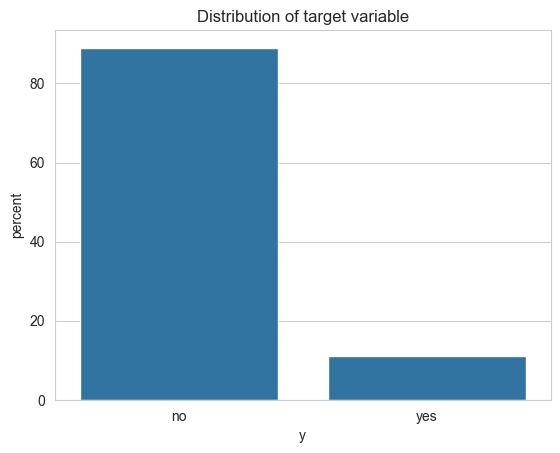

%faliure (no): 10.95%
%sucess (yes): 89.05%


In [3]:
sns.countplot(x='y', data=data, stat='percent')
plt.title('Distribution of target variable')
plt.show()

yes,no = data['y'].value_counts(normalize=True).mul(100).round(2)

print(f'%faliure (no): {no}%\n%sucess (yes): {yes}%')



The target variable is noticably imbalanced. 89% of clients did not subscribe ("no") versus only 11% who did ("yes"). This means accuracy alone is a misleading metric, as a model predicting "no" always would score 89% without learning anything useful. Recall and F1-score are more appropriate here.

### **2.3 Vizualizing numerical & Categorcial Variables**



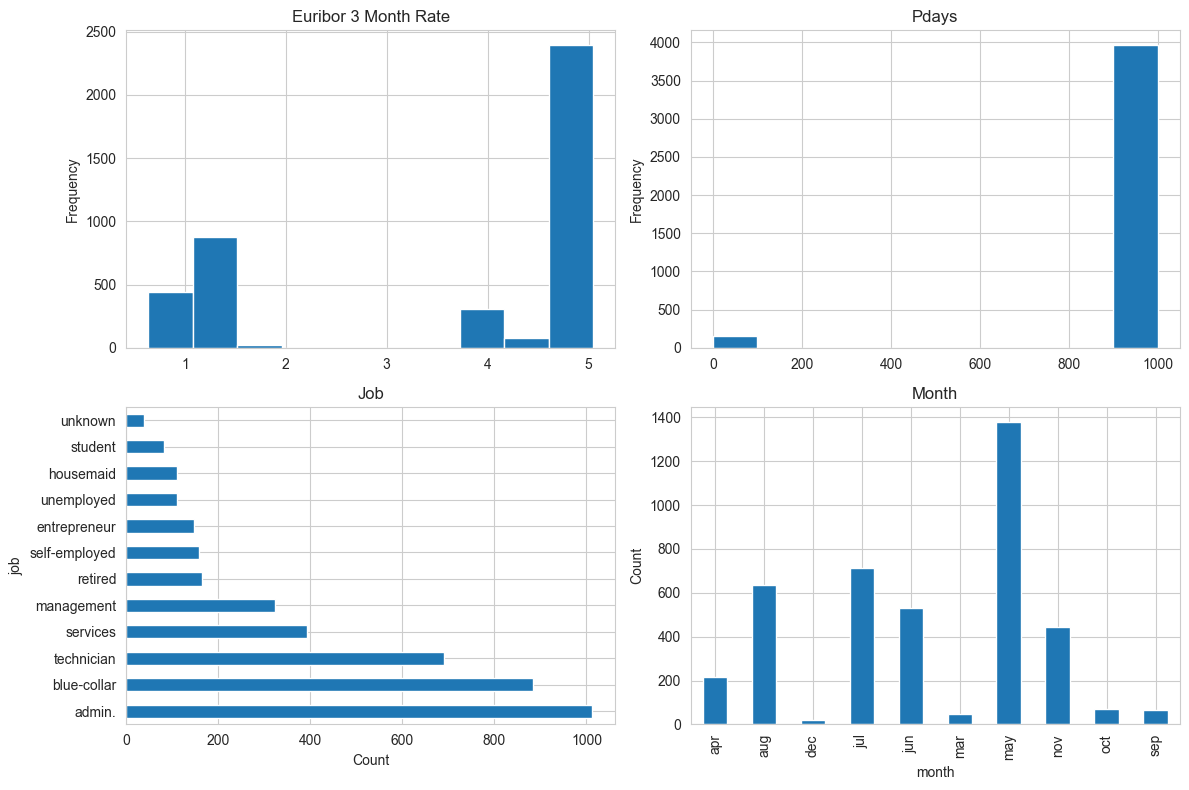

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Numerical
data['euribor3m'].plot(kind='hist', ax=axes[0, 0], title='Euribor 3 Month Rate')
data['pdays'].plot(kind='hist', ax=axes[0, 1], title='Pdays')

# Categorical
data['job'].value_counts().plot(kind='barh', ax=axes[1, 0], title='Job',xlabel = "Count")
data['month'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], title='Month', ylabel='Count')

plt.tight_layout()
plt.show()

**Euribor 3 Month Rate:** The distribution is bimodal, with most values clustered around 1–1.5 and 4.5–5. This suggests the data spans two distinct economic periods with different interest rate environments.

**Pdays:** Heavily dominated by the value 999, confirming that the vast majority of clients were never contacted in a previous campaign. This reinforces that 999 is a sentinel value, not a real measurement.

**Job:** Admin, blue-collar and technician are the most represented job types, while housemaid, student and unknown are the least common.

**Month:** May dominates contact activity by a large margin, followed by July and August. Notably the months are not in chronological order — this should be fixed for clarity. March, October and September saw very few contacts, suggesting the campaign was not active uniformly throughout the year.

###  **2.4 Missing Values**



In [5]:
print(f"Explicit missing values: {data.isna().sum()}") if data.isna().sum().sum() > 0 else print("No explicit missing values")

unknown_count = data.replace('unknown', pd.NA).isna().sum()
print(f"\nImplicit missing values:\n{unknown_count[unknown_count > 0]}")

No explicit missing values

Implicit missing values:
job           39
marital       11
education    167
default      803
housing      105
loan         105
dtype: int64


No explicit missing values (NaN) were found in the raw dataset. However, several categorical columns contain the string "unknown", which is not random noise but rather indicates that information was either unavailable, never recorded, or deliberately withheld by the client.
Before deciding how to handle these entries, it is worth asking: does the absence of information carry meaning in itself? In many real-world scenarios, the fact that a client did not disclose their job type or credit default status may reflect a behavioural pattern that is predictive of the outcome. Automatically imputing or removing these entries would discard that signal entirely, which is a strong assumption to make without justification.
It is therefore important to distinguish between two types of missingness. Explicit missingness, such as NaN, is typically handled through statistical imputation. Implicit or structural missingness, such as the "unknown" category, may encode systemic or behavioural patterns that deserve to be retained as a separate category rather than filled in.
For this reason, "unknown" values were converted to NaN solely to make missingness visible and quantifiable during exploration. The decision of whether to impute, drop, or retain them as a distinct category will be made per variable in the preprocessing stage, based on the extent of missingness and its likely relationship with the target.

The most affected variable is default (19.5% missing), followed by education (4.1%), housing and loan (2.5%), job (0.9%), and marital (0.3%).

### **2.5 Variables that require special consideration**

`duration` must be excluded from any realistic model. It represents the length of the phone call, which is only known after the call has ended — at which point the outcome is already determined. Including it would constitute target leakage, as discussed in Task 1.

`pdays` cannot be treated as a regular numerical variable. As seen in the histogram, roughly 97% of values are 999, which is a sentinel value meaning the client was never previously contacted. The remaining values represent actual days elapsed. This means the column encodes two fundamentally different things at once and will require special treatment before modelling, such as converting 999 into a binary "never contacted" indicator.


# **3. Data Splitting**

The split must occur immediately after loading and identifying the target variable, before any preprocessing step that learns from the data — including imputation, scaling, encoding, resampling, and feature selection.
If splitting were performed later, any transformation fitted on the full dataset would have already seen the validation and test data. For example, a StandardScaler fitted on the entire dataset would compute the mean and standard deviation using test samples, meaning the model indirectly has information about the test set during training. The same applies to imputation — if the mean of a column is computed on all 4,119 rows, that mean is partially determined by test set values, which would not be available at deployment time. This is data leakage: the model is evaluated under conditions that will never exist in production, producing overly optimistic performance estimates that do not reflect true generalization.


### **3.1 Perform Stratified Splitting.**

First we have to separte the dataset from the outcome variable. We get:

The dataset is separated into:
- X: the feature matrix containing all predictor variables.
- y: the target variable representing subscription outcome

Given the strong class imbalance (~11% "yes"), a random split risks producing holdout sets with a different class distribution than the training set. If the validation or test set ends up with fewer "yes" samples than expected, evaluation metrics like recall and F1 become unreliable. Stratification guarantees that each split preserves the original class distribution (approximetly) ensuring that performance estimates on the validation and test sets are representative of the true data distribution.

- Train: 60%
- Test: 20%
- Validation: 20%




In [6]:
X = data.drop(columns='y')
y = data['y']

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)

# Second split: temp into 50/50 validation and test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Shape:\nTrain:{X_train.shape}\nValidation: {X_val.shape}\nTest: {X_test.shape}")

Shape:
Train:(2471, 20)
Validation: (824, 20)
Test: (824, 20)


### **3.2 Verify Stratification**

In [7]:
print(f'Original: \n{round(y.value_counts(normalize=True),5)}')
print(f'\nTrain:\n {round(y_train.value_counts(normalize=True),5)}')
print(f'\nValidation:\n {round(y_val.value_counts(normalize=True),5)}')
print(f'\nTest: \n{round(y_test.value_counts(normalize=True),5)}')

Original: 
y
no     0.89051
yes    0.10949
Name: proportion, dtype: float64

Train:
 y
no     0.89033
yes    0.10967
Name: proportion, dtype: float64

Validation:
 y
no     0.89078
yes    0.10922
Name: proportion, dtype: float64

Test: 
y
no     0.89078
yes    0.10922
Name: proportion, dtype: float64


The output confirms stratification worked correctly — all three sets preserve the original 10.9% minority class proportion. This is exactly what we want.

### **3.3 Split proportions motivation**
A 60/20/20 split was adopted because the dataset contains only 4,119 samples with 11% minority class. Each holdout set must contain enough "yes" samples for reliable evaluation. At 20%, both validation and test sets yield 90 minority class samples, approaching Burkov's ideal of 100. An 80/10/10 split would yield only ~45 "yes" samples per holdout set, below the reliable threshold. A 70/15/15 split yields ~68, better but still short. Since Logistic Regression does not require massive training data, sacrificing 20% training data is justified by the gain in evaluation reliability. The code below showcase this.
**Page 27**

In [8]:
for name, pct in {'80/10/10': 0.1, '70/15/15': 0.15, '60/20/20': 0.2}.items():
    minority = int(len(y) * pct * 0.1095)
    print(f'{name}: {minority} minority class samples per holdout set')

80/10/10: 45 minority class samples per holdout set
70/15/15: 67 minority class samples per holdout set
60/20/20: 90 minority class samples per holdout set



# 4. Managing Missing Values


### 4.1 Missing values & Sentinal numerical values

As identified during the exploratory analysis in Task 2, the dataset contains no explicit missing values but several implicit ones encoded as "unknown", as well as a sentinel value in pdays. Since the split has now been performed, we re-examine missingness exclusively on the training set to ensure no information from the validation or test sets influences any preprocessing decision.

Three types of problematic values were identified:
- explicit missing values (NaN)
- implicit missing values ("unknown")
- sentinel numerical values.

In [9]:
#explicit missing values
print(f"Explicit missing values: {X_train.isna().sum()}") if X_train.isna().sum().sum() > 0 else print("No explicit missing values")

#implicit missing values
unknown_count2 = X_train.replace('unknown', pd.NA).isna().sum()
print(f"\nImplicit missing values:\n{unknown_count2[unknown_count2 > 0]}")

#sentinal values
print(f'\npdays = 999: \n{(X_train["pdays"] == 999).sum()} samples ({(X_train["pdays"] == 999).mean()*100:.1f}%)')


No explicit missing values

Implicit missing values:
job           20
marital        7
education    104
default      492
housing       55
loan          55
dtype: int64

pdays = 999: 
2368 samples (95.8%)


The counts are consistent with what was observed in Task 2, now restricted to the training set.
- `default` remains the most affected variable at ~20% followed by `education`, `housing`, `loan`, `job` and `marital`.
- The pdays sentinel confirms what the histogram already suggested — 95.8% of clients were never previously contacted, meaning this column cannot be treated as a continuous numerical variable, but encodes two fundamentally different states: clients who were previously contacted (4.2%) and clients who were never contacted (95.8%). Treating 999 as a real number and imputing or scaling it alongside genuine day counts would be meaningless. Instead, pdays will be transformed into a binary indicator variable: 0 for never contacted, 1 for previously contacted, effectively replacing the sentinel with an explicit, model-readable signal.

### **4.2 Extent of missingness**
The table below quantifies the extent of missingness for

In [10]:
unknown_count2['pdays'] = (X_train['pdays'] == 999).sum()
pct = (unknown_count2 / len(X_train) * 100).round(2)
pd.DataFrame({'count': unknown_count2[unknown_count2 > 0], '%': pct[pct > 0]})

,count,%
job,20,0.81
marital,7,0.28
education,104,4.21
default,492,19.91
housing,55,2.23
loan,55,2.23
pdays,2368,95.83


### **4.3 Handling missing values**

For categorical variables containing "unknown", the value will be retained as a separate category rather than imputed or removed. This decision is grounded in two considerations.
- First, dropping observations would unnecessarily reduce an already small dataset.
- Second, and more importantly, the reason a client did not disclose information — particularly financial information like default — may itself be predictive of subscription behaviour. Imputing the mode would silently erase this signal. As Burkov notes, the right imputation technique cannot be determined before modelling; retaining "unknown" as a category is the most conservative and transparent choice.

For pdays, the 999 sentinel will be replaced by creating a new binary variable previously_contacted (1 if pdays ≠ 999, 0 otherwise), after which the original pdays column will be dropped. This preserves the structural meaning of the variable without allowing the model to misinterpret 999 as a genuine numerical magnitude.


All transformations that learn from the data — including mode imputation if applied — must be fitted on the training set only and then applied to validation and test sets, as computing statistics on the full dataset would constitute leakage as warned by Burkov.

Rather than dropping pdays entirely, 999 is replaced with 0 and retained alongside previously_contacted, allowing the model to capture both whether a client was previously contacted and how long ago that contact occurred.


In [11]:
# Retain 'unknown' as a separate category - no action needed as it is already a string category

# Create binary indicator for pdays
X_train['previously_contacted'] = (X_train['pdays'] != 999).astype(int)
X_val['previously_contacted'] = (X_val['pdays'] != 999).astype(int)
X_test['previously_contacted'] = (X_test['pdays'] != 999).astype(int)

X_train['pdays'] = X_train['pdays'].replace(999, 0)
X_val['pdays'] = X_val['pdays'].replace(999, 0)
X_test['pdays'] = X_test['pdays'].replace(999, 0)

### **4.4 Operations that needs to be fitted using the training set only (and why)**

Note: Your strategy should distinguish between “data cleaning” decisions (e.g., correcting inconsistent entries)
and “modeling” decisions (e.g., whether missingness itself may carry predictive information).

Any operation that learns a statistic from the data must be fitted on the training set only and then applied to validation and test sets. In this task, two types of decisions were made:

- **Data cleaning decisions** — The pdays binary transformation is a fixed logical rule (999 or not) that requires no fitting. It is applied identically to all three sets without risk of leakage.
- **Modeling decisions** — Retaining "unknown" as a separate category is also a fixed decision requiring no fitting. However, if mode imputation had been chosen for any variable, the mode would need to be computed on the training set only and then used to fill missing values in validation and test sets. Computing it on the full dataset would allow test set information to influence the imputation value, which constitutes leakage as warned by Burkov.
The distinction matters because data cleaning corrects objective inconsistencies that are independent of the data distribution, while modeling decisions — like imputation — estimate properties of the distribution and must therefore be treated with the same discipline as any other learned transformation.




# **5. Encoding Categorical Values**


### **5.1. Identification and classification of categorical variables in the dataset.**

In [12]:
print("Categorical variables:")
print(X_train.select_dtypes(include='str').columns.tolist())

Categorical variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


**Ordinal variables (categories with a meaningful order):**
- **`education`** is the only ordinal variable.
- It follows a clear progression: basic.4y → basic.6y → basic.9y → high.school → professional.course → university.degree.
- This ordering reflects increasing levels of educational attainment and should be preserved during encoding using ordinal encoding rather than one-hot encoding.

**Nominal variables (no intrinsic order):**
All nominal — there is no meaningful ranking between their categories:
- **`job`**
- **`marital`**
- **`contact`**
- **`poutcome`**
- **`default`**
- **`housing`**
- **`loan`**
**`month`** and **`day_of_week`** deserve special mention. While they have a natural temporal order, in this context they represent campaign timing patterns rather than a continuous progression. May having more contacts than March does not imply May is "greater than" March in any meaningful sense for subscription prediction. They are therefore treated as nominal.

### **5.2 Apply an appropriate encoding strategy for each categorical variable.**
- #### For ordinal variables, we use `OrdinalEncoder` with an explicit category order
- #### For nominal variables, we use `OneHotEncoder`

Logistic Regression assumes a linear relationship between the input features and the log-odds of the target. This has direct implications for encoding choices. One-hot encoding is appropriate for nominal variables because it makes no assumption about the relationship between categories — each gets its own coefficient, and the model learns their individual effects independently. Imposing a numeric order on nominal categories like job or marital would force the model to treat the difference between any two adjacent categories as equal, which is an unwarranted assumption that would distort the decision boundary.
For education, ordinal encoding is justified precisely because the ordering is meaningful and the assumption of a monotonic relationship with subscription probability is reasonable — higher education may correlate with greater financial awareness and thus higher subscription rates. Encoding it as ordinal also avoids the dimensionality cost of one-hot encoding while preserving the structure that Logistic Regression can exploit through a single coefficient.

**Both encoders are fitted on the training set only.**

The `OrdinalEncoder` learns the mapping between category strings and integers, and the `OneHotEncoder` learns which categories exist. Fitting on the full dataset would expose the encoders to category distributions from the validation and test sets, constituting leakage.



### **5.3 Analysis of changes due to encoding**

In [13]:
cat_cols = X_train.select_dtypes(include='str').columns.tolist()

ord_columns = ['education']
nom_columns = [column for column in cat_cols if column not in ord_columns]

edu_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
             'high.school', 'professional.course', 'university.degree', 'unknown']

oe = OrdinalEncoder(categories=[edu_order])
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Fit on training set only
X_train_ord_enc = oe.fit_transform(X_train[ord_columns])
X_train_nom_enc = ohe.fit_transform(X_train[nom_columns])

# Apply to validation and test
X_val_ord_enc = oe.transform(X_val[ord_columns])
X_test_ord_enc = oe.transform(X_test[ord_columns])

X_val_nom_enc = ohe.transform(X_val[nom_columns])
X_test_nom_enc = ohe.transform(X_test[nom_columns])

print(f'Education encoded into {X_train_ord_enc.shape[1]} ordinal column')
print(f'Nominal variables expanded into {X_train_nom_enc.shape[1]} binary columns after one-hot encoding')

Education encoded into 1 ordinal column
Nominal variables expanded into 36 binary columns after one-hot encoding


In [14]:
numerical_cols = X_train.select_dtypes(exclude='str').columns.tolist()
total_after = len(numerical_cols) + X_train_ord_enc.shape[1] + X_train_nom_enc.shape[1]

print(f'Features before encoding: {X_train.shape[1]}')
print(f'Features after encoding:  {total_after}')
print(f'  - Numerical (unchanged): {len(numerical_cols)}')
print(f'  - Ordinal (education):   {X_train_ord_enc.shape[1]}')
print(f'  - One-hot encoded:       {X_train_nom_enc.shape[1]}')

Features before encoding: 21
Features after encoding:  48
  - Numerical (unchanged): 11
  - Ordinal (education):   1
  - One-hot encoded:       36


#### **Dimensionality**

Encoding increased the number of features from the original count to the total above. One-hot encoding is the main driver of this expansion, as each nominal variable is replaced by multiple binary columns. The drop='first' argument reduces this slightly by dropping one reference category per variable to avoid multicollinearity.

#### **Interpretability**

Each one-hot coefficient represents the effect of belonging to a specific category relative to the dropped reference category, holding all else equal. The ordinal coefficient for education represents the change in log-odds associated with moving one step up the education scale. Both are interpretable, but the analyst must keep track of which reference categories were dropped.

#### **Decision boundaries**

Without encoding, a linear model cannot process categorical variables at all. After one-hot encoding, Logistic Regression can assign a separate weight to each category, effectively learning category-specific shifts in the decision boundary. Ordinal encoding allows the model to capture a monotonic relationship between education level and subscription probability, which is a reasonable assumption given the natural ordering.


# **6. Feature Scaling**



### **6.1. Numerical variables that require scaling.**


In [15]:
numerical_cols = X_train.select_dtypes(exclude='str').columns.tolist()

print(numerical_cols)
print(f'\nSummary statistics:')
X_train[numerical_cols].describe().round(2)

['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted']

Summary statistics:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,previously_contacted
count,2471.00,2471.00,2471.00,2471.00,2471.00,2471.00,2471.00,2471.00,2471.00,2471.00,2471.00
mean,40.12,258.02,2.57,0.24,0.20,0.06,93.57,-40.43,3.60,5165.10,0.04
std,10.32,266.41,2.68,1.41,0.57,1.57,0.59,4.66,1.74,74.03,0.20
min,18.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.64,4963.60,0.00
25%,32.00,102.00,1.00,0.00,0.00,-1.80,93.08,-42.70,1.33,5099.10,0.00
50%,38.00,181.00,2.00,0.00,0.00,1.10,93.75,-41.80,4.86,5191.00,0.00
75%,47.00,314.00,3.00,0.00,0.00,1.40,93.99,-36.40,4.96,5228.10,0.00
max,86.00,3643.00,35.00,19.00,6.00,1.40,94.77,-26.90,5.04,5228.10,1.00


**`duration`** is kept for benchmark purposes as discussed in Task 1
- it will be excluded from the realistic model when training Logistic Regression
- two models will be trained: one with duration (benchmark) and one without (realistic)

Looking at the summary statistics, all numerical variables except **`previously_contacted`** require scaling.
- The ranges vary enormously — **`nr.employed`** ranges from 4963 to 5228, **`duration`** from 0 to 3643, while **`emp.var.rate`** ranges from -3.4 to 1.4.
- When features operate on such different scales, Logistic Regression's gradient-based optimization will update weights unevenly — features with large ranges dominate the gradient steps while features with small ranges are effectively ignored.
- **`previously_contacted`** is excluded from scaling since it is a binary indicator (0/1) created from the pdays sentinel. Scaling it would distort its meaning — it does not represent a continuous measurement but a categorical state.
- **`duration`** is kept unscaled for now and will be handled at the modelling stage where two models will be compared — a benchmark model including duration and a realistic model without it.
-
The variables requiring scaling are therefore: **`age`**, **`campaign`**, **`previous`**, **`emp.var.rate`**, **`cons.price.idx`**, **`cons.conf.idx`**, **`euribor3m`** and **`nr.employed`**.

### **6.2 Scaling numerical variables (and choice of method)**

StandardScaler is chosen over MinMaxScaler for three reasons, each grounded in the mathematical behavior of Logistic Regression.

1. **Logistic Regression minimizes log-loss via gradient descent.** Unscaled features produce an elongated loss surface where gradients are steep in some directions and shallow in others, causing the optimizer to zigzag. Standardization produces a more spherical loss surface, making gradient descent converge faster and more reliably.

2. **Campaign and duration are right-skewed with outliers.** MinMaxScaler maps all values to [0,1] but is highly sensitive to extreme values — a single outlier compresses all remaining values into a narrow band, distorting the feature. StandardScaler is more robust since it scales by standard deviation rather than range.

3. **Logistic Regression applies L2 regularization by default**, penalizing the sum of squared coefficients. If features are unscaled, features with small ranges produce artificially large coefficients just to compensate for their scale, and regularization penalizes them disproportionately. Standardization ensures the penalty is applied fairly and that the hyperparameter C has a consistent effect across all features.

In [16]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val_scaled[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\n--- Mean and Standard Deviation of Standardized Data ---")
print("Means:\n", X_train_scaled[numerical_cols].mean().round(5))
print("\nStandard Deviations:\n", X_train_scaled[numerical_cols].std().round(5))


--- Mean and Standard Deviation of Standardized Data ---
Means:
 age                    -0.0
duration                0.0
campaign               -0.0
pdays                   0.0
previous               -0.0
emp.var.rate            0.0
cons.price.idx         -0.0
cons.conf.idx           0.0
euribor3m              -0.0
nr.employed             0.0
previously_contacted    0.0
dtype: float64

Standard Deviations:
 age                     1.0002
duration                1.0002
campaign                1.0002
pdays                   1.0002
previous                1.0002
emp.var.rate            1.0002
cons.price.idx          1.0002
cons.conf.idx           1.0002
euribor3m               1.0002
nr.employed             1.0002
previously_contacted    1.0002
dtype: float64


### **6.3 Transformations to be fitted soley on the training set (and why)**



The scaler is fitted on the training set only using fit_transform, and then the learned mean and standard deviation are applied to validation and test sets using transform only.

If we fitted the scaler on the full dataset, the mean and standard deviation would be computed using values from the validation and test sets. This means the training data would be scaled using statistics that were partially determined by held-out data — the model would indirectly have access to information it should never see during training. This is leakage, and it would produce overly optimistic evaluation results that do not reflect true generalization performance.

The same principle applies to any transformation that computes a statistic from the data: OrdinalEncoder, OneHotEncoder, and StandardScaler must all be fitted on the training set only. Fixed transformations like the pdays binary indicator require no fitting and are therefore safe to apply identically across all three sets.

### **6.4 How feature scaling effects...**





#### **1. Gradient-based optimization**

Logistic Regression minimizes the log-loss using gradient descent. When features have very different scales, the loss surface becomes elongated — gradients are steep in directions corresponding to small-scale features and shallow in directions corresponding to large-scale features. This causes the optimizer to zigzag rather than converge directly, slowing down training significantly. After standardization, the loss surface becomes more spherical and gradient descent converges faster and more reliably.

#### **2. Magnitude and comparability of coefficients**

Before scaling, a coefficient's magnitude is influenced by the scale of its feature rather than its true predictive importance. For example, nr.employed ranges over hundreds of units while emp.var.rate ranges over a few units — their raw coefficients are therefore not directly comparable. After standardization, all features have mean 0 and standard deviation 1, so coefficients reflect the change in log-odds associated with a one standard deviation change in each feature. This makes coefficients directly comparable and interpretable.

#### **3. Regularization penalties**

Logistic Regression applies L2 regularization by default, penalizing large coefficients to prevent overfitting. If features are unscaled, features with small ranges will have artificially large coefficients just to compensate for their scale, and the regularizer will penalize them disproportionately — effectively shrinking informative features more than uninformative ones. After standardization, the regularization penalty is applied fairly across all features, and the regularization hyperparameter C has a consistent and interpretable effect regardless of which feature it acts on.


# **7. Feature Selection**


### **7.1. Identification and handling of potential features with very low variance**

**The threshold of < 0.01 is chosen.**
- A feature with near-zero variance carries almost no information — it is approximately constant across all observations and therefore cannot help the model discriminate between classes.
- After standardization, all features have variance of approximately 1 by definition, so low variance features would only appear if a feature is nearly constant before scaling.

In [17]:
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train_scaled[numerical_cols])

variances = pd.Series(selector.variances_, index=numerical_cols).sort_values()

print('Variances of numerical features:')
print(variances.round(4))
print(f'\nFeatures below threshold (0.01): {list(variances[variances < 0.01].index)}')

Variances of numerical features:
euribor3m               1.0
previously_contacted    1.0
cons.conf.idx           1.0
age                     1.0
campaign                1.0
previous                1.0
emp.var.rate            1.0
cons.price.idx          1.0
nr.employed             1.0
pdays                   1.0
duration                1.0
dtype: float64

Features below threshold (0.01): []


No features were removed on the basis of low variance. After standardization, all numerical features have a variance of exactly 1 by definition of StandardScaler.

### **7.2 Highly correlated numerical features and whether any should be removed**

#### Choosen threshold = 0.85

The threshold of 0.85 was chosen deliberately over 0.80 to avoid removing pdays and previously_contacted, which show a correlation of 0.82. Although one is derived from the other, they capture conceptually distinct information — whether a client was previously contacted and how long ago — and both are therefore retained.

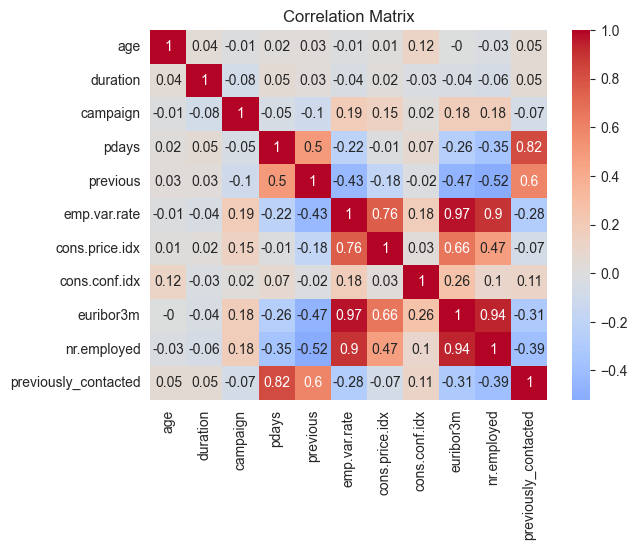

Highly correlated pairs (|r| > 0.85):
      * euribor3m & emp.var.rate: 0.97
      * nr.employed & emp.var.rate: 0.9
      * nr.employed & euribor3m: 0.94

                  feature    VIF
8              euribor3m  61.68
5           emp.var.rate  33.16
9            nr.employed  30.41
6         cons.price.idx   6.54
10  previously_contacted   3.66
3                  pdays   3.12
7          cons.conf.idx   2.53
4               previous   1.85
2               campaign   1.05
0                    age   1.02
1               duration   1.02


In [18]:
numerical_cols = X_train_scaled.select_dtypes(exclude='str').columns.tolist()

corr_matrix = X_train_scaled[numerical_cols].corr().round(2)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

threshold = 0.85
high_corr = [(corr_matrix.columns[i], corr_matrix.columns[j], round(corr_matrix.iloc[i,j], 2))
             for i in range(len(corr_matrix.columns))
             for j in range(i)
             if abs(corr_matrix.iloc[i,j]) > threshold]

print("Highly correlated pairs (|r| > 0.85):")
for i, j, corr in high_corr:
    print(f'      * {i} & {j}: {corr}')

vif = pd.DataFrame({'feature': numerical_cols,
                    'VIF': [variance_inflation_factor(X_train_scaled[numerical_cols].values, i)
                            for i in range(len(numerical_cols))]})
print("\n",vif.sort_values('VIF', ascending=False).round(2))

Three pairs of highly correlated features were identified above the threshold of 0.85, all involving macroeconomic indicators:

- **`euribor3m`**  &  **`emp.var.rate`**   ---> correlation = 0.97
- **`nr.employed`**  &  **`emp.var.rate`** ---> correlation = 0.9
- **`nr.employed`**  &  **`euribor3m`**    ---> correlation = 0.94

This is confirmed by the VIF scores, where:
- euribor3m (61.68)
- emp.var.rate (33.16)
- nr.employed (30.41)
all far exceed the threshold of 10, indicating severe multicollinearity.

These three variables all capture the same underlying macroeconomic climate:
- when the economy is performing well --> employment is high --> the Euribor rate is high --> and the employment variation rate is positive.
- Retaining all three provides no additional information to the model but inflates coefficient variance, making them unstable and hard to interpret.

- **`euribor3m`** is retained as it is a daily indicator, making it the most granular and temporally responsive of the three.
- **`emp.var.rate`** and **`nr.employed`** are quarterly indicators and are therefore redundant given **`euribor3m`** is already present.

Dropping them reduces multicollinearity while preserving the macroeconomic signal.

In [19]:
cols_to_remove = ['emp.var.rate', 'nr.employed']

X_train_scaled = X_train_scaled.drop(columns=cols_to_remove)
X_val_scaled = X_val_scaled.drop(columns=cols_to_remove)
X_test_scaled = X_test_scaled.drop(columns=cols_to_remove)

#update numerical & categorical cols:
numerical_cols = X_train_scaled.select_dtypes(exclude='str').columns.tolist()
cat_cols = X_train_scaled.select_dtypes(include='str').columns.tolist()

print(f'Remaining numerical features: {numerical_cols}')

vif_after = pd.DataFrame({'feature': numerical_cols,
                          'VIF_after': [variance_inflation_factor(X_train_scaled[numerical_cols].values, i)
                                        for i in range(len(numerical_cols))]})

# Merge side by side


vif_after = pd.DataFrame({'feature': numerical_cols,
                    'VIF after': [variance_inflation_factor(X_train_scaled[numerical_cols].values, i)
                            for i in range(len(numerical_cols))]})

vif_comparison = vif.merge(vif_after, on='feature', how='left')
print(vif_comparison.sort_values('VIF', ascending=False).round(2))

Remaining numerical features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'previously_contacted']
                 feature    VIF  VIF after
8              euribor3m  61.68       2.71
5           emp.var.rate  33.16        NaN
9            nr.employed  30.41        NaN
6         cons.price.idx   6.54       2.00
10  previously_contacted   3.66       3.65
3                  pdays   3.12       3.09
7          cons.conf.idx   2.53       1.22
4               previous   1.85       1.84
2               campaign   1.05       1.04
0                    age   1.02       1.02
1               duration   1.02       1.01


**Evaluation**
The VIF comparison confirms that removing emp.var.rate and nr.employed was effective. euribor3m dropped dramatically from 61.68 to 2.71, falling well below the threshold of 10. All remaining features now have VIF scores below 4, indicating no problematic multicollinearity. The removed features show NaN as expected since they no longer exist in the reduced feature set. The macroeconomic signal is fully preserved through euribor3m alone.


### **7.3 Conceptual feature removal**

Two features require removal based on conceptual rather than statistical grounds.
duration has already been discussed extensively in Task 1. It is not available at prediction time since the length of a call is only known after the call ends — at which point the outcome is already determined. It will be excluded from the realistic model and retained only in the benchmark model as discussed in Task 6.
No other features present availability concerns at prediction time. All remaining variables — demographic, financial, campaign-related and macroeconomic — are either known before the call is made or represent external indicators that are publicly available.


### **7.4 Why feature selection must use the training set only**

Feature selection must be performed on the training set only for the same reason as any other data-driven transformation — it learns from the data. Variance thresholds, correlation coefficients and VIF scores are all statistics computed from the feature values. If computed on the full dataset, they would be influenced by the distribution of validation and test examples, meaning the decision of which features to keep or drop would have been partly determined by held-out data. This constitutes leakage. The consequences are subtle but real — features that appear uninformative on the full dataset may carry signal that is only present in the test set, or vice versa, leading to evaluation results that do not reflect true generalization performance.


### **7.5 Consequences of Performing Feature Selection Before Splitting**

Performing feature selection on the entire dataset before splitting would constitute data leakage. The correlation and VIF statistics would be computed using information from the validation and test sets, meaning the feature selection decision would be partially guided by data the model should never have seen. This produces an overly optimistic pipeline where the selected features are tuned to the full dataset rather than generalizing to unseen data.

For Logistic Regression specifically, the consequences are more pronounced than for other models. Logistic Regression assumes that the selected features have a stable linear relationship with the log-odds of the target. If feature selection is performed on the full dataset, this stability is assessed on data that includes the test set — a distribution the model will only encounter after training. If the test set happens to contain slightly different correlations or variances than the training set, the selected feature set may be suboptimal for the training distribution specifically, leading to unstable coefficients and poor generalization.

Multicollinearity is particularly relevant here. If highly correlated features like euribor3m, emp.var.rate and nr.employed are assessed for redundancy on the full dataset, the measured correlations reflect the global distribution. In practice, the training set correlation may differ slightly, meaning a feature that appears redundant globally may carry independent signal in the training set. Dropping it based on full-dataset statistics would remove potentially useful information from the model without justification from the data it actually trains on.


# 8. Addressing Class Imbalance


### **8.1 Quantifiyng and adressing class imbalance**

In [20]:
print(f'Class distribution in training set:')
print(y_train.value_counts())
print(f'\n{y_train.value_counts(normalize=True).mul(100).round(2)}')

Class distribution in training set:
y
no     2200
yes     271
Name: count, dtype: int64

y
no     89.03
yes    10.97
Name: proportion, dtype: float64


#### **The training set contains:**
- 2,200 "no" samples (89.03%)
- 271 "yes" samples (10.97%).

This confirms the class imbalance identified during exploration in Task 2, preserved exactly as expected from the stratified split.


### **8.2 Is class imbalance a concern? How does it affect evaluation metrics?**

YES, for theese 3 main reasons:

**1. Algorithmic bias toward the majority class.**

As discussed in Lecture 3, learning algorithms weight errors equally across classes by default. With 89% of examples belonging to "no", the model is implicitly rewarded for predicting "no" and has little incentive to learn the minority class signal. Burkov confirms in Section 3.9 that when 90% of examples belong to one class, standard formulations that equally weight errors across classes will not be effective.

**2. Misleading evaluation metrics.**

This algorithmic bias directly corrupts standard evaluation. A Zero Rule baseline that always predicts "no" achieves 89% accuracy without learning anything — making raw accuracy a completely uninformative metric. The three metrics that matter are:

- **Accuracy** — rendered meaningless by imbalance. A model predicting "no" for every client scores 89% while failing entirely at its commercial purpose.
- **Precision** — measures how many predicted "yes" cases are actually correct. A conservative model that rarely predicts "yes" can inflate precision while missing most true subscribers.
- **Recall** — the most business-critical metric. Missing a true subscriber means the bank fails to contact a client who would have subscribed, directly reducing campaign revenue. A majority-class-dominated model will have critically low recall on the minority class even if accuracy and precision appear acceptable.

**3. Business relevance of the minority class.**

As Lecture 3 notes, class imbalance causes measures of efficiency to become skewed — the model appears useful by standard metrics while being commercially useless. Missing a true subscriber (false negative) is far more costly than incorrectly flagging a non-subscriber (false positive). Precision, recall, and F1-score must therefore be the primary evaluation metrics for this task.



### **8.3 Resampling (Random Oversampling)**.

Random oversampling is applied to the training set only, after splitting, encoding and scaling.








In [21]:
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print(f'Before resampling: {y_train.value_counts().to_dict()}')
print(f'After resampling:  {y_train_ros.value_counts().to_dict()}')

Before resampling: {'no': 2200, 'yes': 271}
After resampling:  {'no': 2200, 'yes': 2200}


ROS works by duplicating existing minority class examples until both classes are balanced.
- The result is a training set of 4,400 samples with equal class representation --> 2,200 `no` and 2,200 `yes`

### **8.4 Justifying choice of Resampling technique (ROS)**

As described by Burkov, oversampling works by making multiple copies of minority class examples, increasing their weight in the loss function. The core assumption is simple: duplicating real examples is sufficient to rebalance the class distribution and force the learning algorithm to weight errors on both classes equally. For Logistic Regression, which minimizes log-loss via gradient descent, this directly addresses the problem identified in Lecture 3 — that learning algorithms equally weight errors across classes, causing the majority class to dominate gradient updates. By duplicating minority class examples, each gradient update sees more "yes" examples, pushing the decision boundary toward better minority class separation.

**Why not SMOTE or ADASYN:**

As Burkov explains, both methods generate synthetic examples by interpolating between existing minority class examples using k-nearest neighbors: x_new = x_i + λ(x_zi − x_i). This interpolation is rejected for three compounding reasons:

- **Dataset size:** With only 271 minority class examples, the neighborhood structure is sparse. Synthetic examples risk being generated in regions that do not accurately represent true subscriber behaviour.
- **Feature space:** After one-hot encoding, many features are binary (0/1). Interpolating between them produces non-binary values (e.g., 0.3 or 0.7) with no meaningful interpretation.
- **Model choice:** SMOTE's boundary-focused synthesis is most beneficial for non-linear models like decision trees. For Logistic Regression, which learns a single global decision boundary, what matters is equal class weighting during gradient descent — which random oversampling achieves more safely through duplication of real examples.



### **8.5 Why resampling should occur here**

Resampling must occur after splitting and after all preprocessing steps that learn from the data, but strictly before model training. This ordering is not arbitrary — it follows directly from the data leakage principles established by Burkov and Lecture 4.

**1. After splitting — not before.**

As Burkov states in Section 3.6, Condition 1 of good partitioning is that "the split was applied to raw data before everything else." If resampling were applied before splitting, duplicate minority class examples would be generated across the entire dataset before any holdout sets are defined. When the split is subsequently performed, identical or near-identical examples would appear in both the training and validation sets. The model would effectively be evaluated on examples it was trained on, directly violating the requirement that holdout sets contain only unseen data.

The implications for model evaluation are severe. As Lecture 4 warns, this type of leakage does not cause the model to fail visibly — instead, "the model just lies": it produces systematically over-optimistic performance estimates that do not reflect true generalization. Precision, recall, and AUC scores on the validation set would all be inflated, making it impossible to make reliable decisions about model quality or pipeline configuration.

**2. After encoding and scaling — not before.**

Resampling must be applied to the fully preprocessed training data. If applied before encoding, raw string values would be duplicated rather than their numerical representations. If applied before scaling, the StandardScaler would compute mean and standard deviation on an artificially inflated training set, introducing subtle distributional distortions into the scaled features.

**3. Validation and test sets are never resampled.**

As Lecture 3 explicitly states, resampling is part of the training procedure only. Validation and test sets must preserve the original 89/11 class distribution to accurately simulate real deployment conditions — where class imbalance is present and the model must perform under realistic data distributions. Resampling the holdout sets would make evaluation artificially easier and produce metrics that are meaningless for deployment.




# **9. Training a Logistic Regression Model**


### **9.1 Assemble final feature matrix**

In [22]:
cols_to_drop = nom_columns + ord_columns

X_train_final = pd.concat([
    X_train_scaled.drop(columns=cols_to_drop).reset_index(drop=True),
    pd.DataFrame(X_train_ord_enc, columns=ord_columns),
    pd.DataFrame(X_train_nom_enc, columns=ohe.get_feature_names_out(nom_columns))
], axis=1)

X_val_final = pd.concat([
    X_val_scaled.drop(columns=cols_to_drop).reset_index(drop=True),
    pd.DataFrame(X_val_ord_enc, columns=ord_columns),
    pd.DataFrame(X_val_nom_enc, columns=ohe.get_feature_names_out(nom_columns))
], axis=1)

print(f'X_train_final shape: {X_train_final.shape}')
print(f'X_val_final shape:   {X_val_final.shape}')

X_train_final shape: (2471, 46)
X_val_final shape:   (824, 46)


### **9.2 Training a Logistic Regression model (to predict y).**



In [23]:
# Model 1 - Benchmark model = Without  resampling
lr_m1 = LogisticRegression(random_state=42, max_iter=1000)
lr_m1.fit(X_train_final, y_train)

y_pred_m1 = lr_m1.predict(X_val_final)
y_prob_m1 = lr_m1.predict_proba(X_val_final)[:, 1]

# Model 2: With Resampling
ros = RandomOverSampler(random_state=42)
X_train_ros_final, y_train_ros_final = ros.fit_resample(X_train_final, y_train)

lr_m2 = LogisticRegression(random_state=42, max_iter=1000)
lr_m2.fit(X_train_ros_final, y_train_ros_final)

y_pred_m2 = lr_m2.predict(X_val_final)
y_prob_m2 = lr_m2.predict_proba(X_val_final)[:, 1]

# Model 3: Benchmark model but WITHOUT duration
X_train_m3 = X_train_final.drop(columns=['duration'])
X_val_m3 = X_val_final.drop(columns=['duration'])

lr_m3 = LogisticRegression(random_state=42, max_iter=1000)
lr_m3.fit(X_train_m3, y_train)

y_pred_m3 = lr_m3.predict(X_val_m3)
y_prob_m3 = lr_m3.predict_proba(X_val_m3)[:, 1]

print(f'Predictions made on {len(y_pred_m1)} validation examples\n')

print(f'Model 1: Benchmark model without  resampling')
print(f'Predicted "yes": {sum(y_pred_m1 == "yes")}')
print(f'Predicted "no":  {sum(y_pred_m1 == "no")}\n')

print(f'Model 2: With Resampling')
print(f'Predicted "yes": {sum(y_pred_m2 == "yes")}')
print(f'Predicted "no":  {sum(y_pred_m2 == "no")}\n')

print(f'Model 3:  WITHOUT duration')
print(f'Predicted "yes": {sum(y_pred_m3 == "yes")}')
print(f'Predicted "no":  {sum(y_pred_m3 == "no")}')



Predictions made on 824 validation examples

Model 1: Benchmark model without  resampling
Predicted "yes": 48
Predicted "no":  776

Model 2: With Resampling
Predicted "yes": 156
Predicted "no":  668

Model 3:  WITHOUT duration
Predicted "yes": 27
Predicted "no":  797


### **9.3 Accuracy, Precision, and Recall on the validation set**

In [24]:
results = pd.DataFrame({'Model': ['M1: No resample (benchmark)', 'M2: Resampled', 'M3: No resample, no duration'],
                        'Accuracy':[accuracy_score(y_val, y_pred_m1), accuracy_score(y_val, y_pred_m2), accuracy_score(y_val, y_pred_m3)],
                        'Precision':[precision_score(y_val, y_pred_m1, pos_label='yes'), precision_score(y_val, y_pred_m2, pos_label='yes'), precision_score(y_val, y_pred_m3, pos_label='yes')],'Recall':[recall_score(y_val, y_pred_m1, pos_label='yes'), recall_score(y_val, y_pred_m2, pos_label='yes'), recall_score(y_val, y_pred_m3, pos_label='yes')],
                        'F1':[f1_score(y_val, y_pred_m1, pos_label='yes'), f1_score(y_val, y_pred_m2, pos_label='yes'), f1_score(y_val, y_pred_m3, pos_label='yes')],
                        'ROC-AUC':[roc_auc_score((y_val=='yes').astype(int), y_prob_m1), roc_auc_score((y_val=='yes').astype(int), y_prob_m2), roc_auc_score((y_val=='yes').astype(int), y_prob_m3)]}).round(4)

print(results.to_string(index=False))

                       Model  Accuracy  Precision  Recall     F1  ROC-AUC
 M1: No resample (benchmark)    0.9053     0.6250  0.3333 0.4348   0.9219
               M2: Resampled    0.8762     0.4615  0.8000 0.5854   0.9236
M3: No resample, no duration    0.9041     0.7037  0.2111 0.3248   0.7951


The accuracy of 90.53% is only marginally better than the Zero Rule baseline of 89.08%, confirming that accuracy alone is uninformative for this imbalanced problem. As Burkov notes in Section 5.1.4, a model must meaningfully outperform the baseline to demonstrate value — a 1.46 percentage point gain does not achieve this on accuracy alone.
Precision of 0.625 indicates that when the model predicts "yes" it is correct 62.5% of the time, showing the model has learned a genuine signal. However recall of 0.333 means it only identifies 1 in 3 actual subscribers, missing the majority. The F1 score of 0.435 reflects this imbalance between precision and recall. For a bank marketing campaign where missing a true subscriber is the costliest error, this recall is commercially insufficient — but the results are sensible and confirm the preprocessing pipeline is coherent and correctly implemented.

### **9.4 Accuracy vs. Zero-Rule baseline**

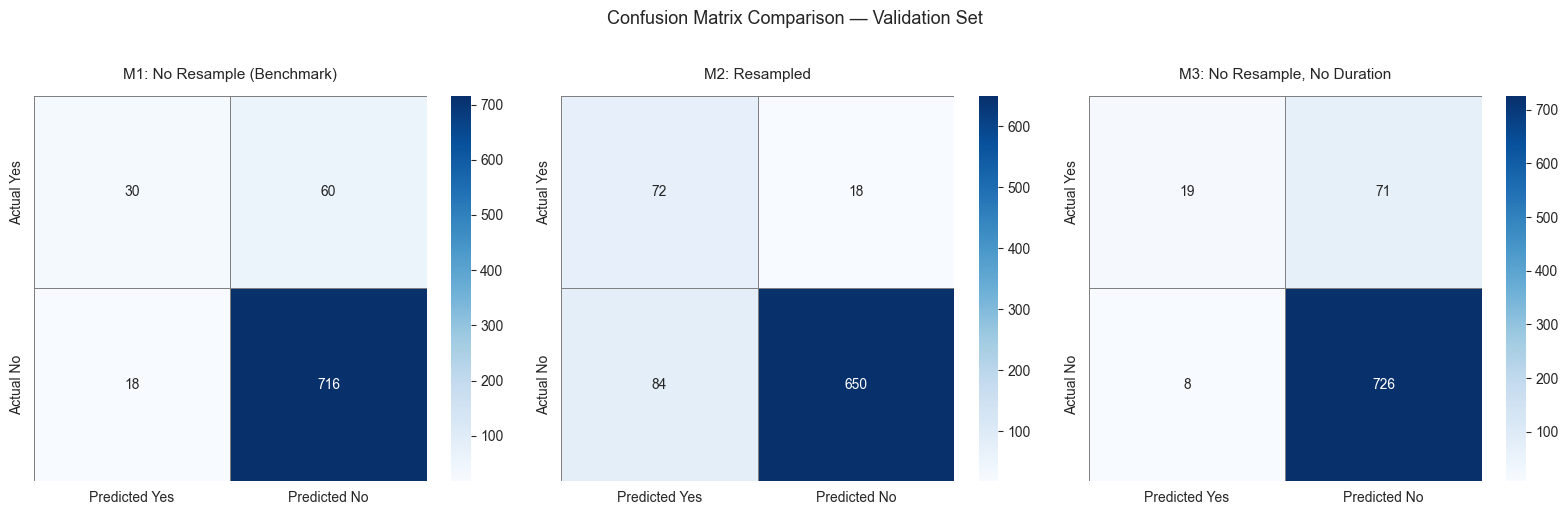

Zero Rule Baseline Accuracy: 0.8908

M1: No Resample (Benchmark)    Accuracy: 0.9053  Improvement: 0.0146
M2: Resampled                  Accuracy: 0.8762  Improvement: -0.0146
M3: No Resample, No Duration   Accuracy: 0.9041  Improvement: 0.0133


In [25]:

# --- Zero Rule Baseline ---
zero_rule_acc = (y_val == 'no').mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = [
    (y_pred_m1, 'M1: No Resample (Benchmark)'),
    (y_pred_m2, 'M2: Resampled'),
    (y_pred_m3, 'M3: No Resample, No Duration')
]

for ax, (y_pred, title) in zip(axes, models):
    cm = confusion_matrix(y_val, y_pred, labels=['yes', 'no'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Yes', 'Predicted No'],
                yticklabels=['Actual Yes', 'Actual No'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(title, fontsize=11, pad=12)

plt.suptitle('Confusion Matrix Comparison — Validation Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Comparison ---
print(f'Zero Rule Baseline Accuracy: {zero_rule_acc:.4f}\n')
print(f'M1: No Resample (Benchmark)    Accuracy: {accuracy_score(y_val, y_pred_m1):.4f}  Improvement: {accuracy_score(y_val, y_pred_m1) - zero_rule_acc:.4f}')
print(f'M2: Resampled                  Accuracy: {accuracy_score(y_val, y_pred_m2):.4f}  Improvement: {accuracy_score(y_val, y_pred_m2) - zero_rule_acc:.4f}')
print(f'M3: No Resample, No Duration   Accuracy: {accuracy_score(y_val, y_pred_m3):.4f}  Improvement: {accuracy_score(y_val, y_pred_m3) - zero_rule_acc:.4f}')


**Confusion Matrix & Zero Rule Interpretation**

The Zero Rule baseline achieves 89.08% accuracy by always predicting "no", never identifying a single subscriber. All three models must be evaluated against this reference point.

**M1 (No Resampling, Benchmark)** is conservative — it correctly identifies 30 subscribers (TP) but misses 60 (FN). Accuracy improves marginally over baseline by 1.46 points, but the model catches only 1 in 3 actual subscribers. The low FP count of 18 reflects high precision but commercially insufficient recall.

**M2 (Resampled)** shows the clearest effect of random oversampling. True positives jump from 30 to 72, and false negatives drop dramatically from 60 to 18 — the model now catches 4 in 5 actual subscribers. The cost is more false positives (84) and a slight accuracy drop of 1.46 points below baseline. As Burkov confirms in Section 5.1.4, accuracy below baseline does not mean the model is worse — it means the model has shifted its decision boundary to prioritize the minority class, which is exactly the intended effect of resampling.

**M3 (No Resampling, No Duration)** is the realistic model — duration is removed as it constitutes leakage. True positives drop to 19 and false negatives rise to 71, confirming that duration was carrying significant predictive weight. The ROC-AUC drop from 0.92 to 0.80 quantifies the leakage effect. This is the only model that could realistically be deployed in production.


# 10. Final Comments

### **10.1 Adressing Data Leakage**

The test set has remained completely sealed throughout the entire notebook. No preprocessing statistics, encoding decisions, scaling parameters, feature selection choices, or resampling operations were fitted on or informed by the test set.

To formally verify this, two checks are performed:
1. confirm that the test set class distribution still reflects the original 89/11 split from stratification — confirming it was never resampled or modified.
2. confim that there is zero index overlap between all three sets — confirming no examples leaked between splits.

In [26]:
# --- Verify test set has never been touched ---
print(f'Test set size: {X_test.shape[0]} samples')
print(f'Test set class distribution:')
print(y_test.value_counts())
print(f'Test minority class proportion: {y_test.value_counts(normalize=True)["yes"]:.4f}')

# --- Verify no overlap between sets ---
train_idx = set(X_train.index)
val_idx = set(X_val.index)
test_idx = set(X_test.index)

print(f'\nLeakage Check')
print(f'Train/Val overlap:  {len(train_idx & val_idx)} samples')
print(f'Train/Test overlap: {len(train_idx & test_idx)} samples')
print(f'Val/Test overlap:   {len(val_idx & test_idx)} samples')
print(f'Total samples I have accounted for: {len(train_idx | val_idx | test_idx)} (should be {len(X)})')

Test set size: 824 samples
Test set class distribution:
y
no     734
yes     90
Name: count, dtype: int64
Test minority class proportion: 0.1092

Leakage Check
Train/Val overlap:  0 samples
Train/Test overlap: 0 samples
Val/Test overlap:   0 samples
Total samples I have accounted for: 4119 (should be 4119)


Zero overlap across all three sets and a preserved 89/11 minority class proportion confirm the test set integrity.

The implications of this are significant.
- As Burkov states in Section 3.6, the test set must come from the same statistical distribution as the validation set and must never be seen by the learning algorithm or used to inform any pipeline decision.
- Violating this would produce overly optimistic performance estimates that do not reflect true generalization — the model would appear to perform better than it actually would in production.
- The test set therefore remains available for one final, unbiased evaluation of the best performing model identified on the validation set — M2 (Resampled) — which would constitute the final reported performance of this pipeline.

### **10.2 Final Word**

The central challenge of this project was not technical — it was judgement. Every preprocessing decision forced a choice between what is measurable and what is deployable. duration predicts subscription better than almost any other feature, yet it cannot exist at prediction time. Resampling dramatically improves recall, yet it makes the model appear worse by conventional accuracy standards. Retaining "unknown" as a category rather than imputing it preserves a behavioral signal that mode imputation would silently destroy.
These tensions do not resolve neatly. The best model on the validation set is not the model you would deploy. The model you would deploy performs modestly — recall of 0.21, ROC-AUC of 0.80 — not because the pipeline failed, but because the data genuinely makes this a hard problem. A bank marketing dataset where 89% of clients say no, where the most predictive feature is only known after the intervention has already occurred, and where the commercially valuable class has only 271 training examples, sets a ceiling on what any linear model can achieve.
The honest conclusion is that this pipeline is correct, but correctness is a floor not a ceiling. What comes next — hyperparameter tuning, non-linear models, cost-sensitive learning — is not refinement. It is the actual problem.